**<center>INSTALL FER-2013 data set and install packages</center>**

The following code has been generate using "ChatGPT" on "5/7/2026" with the following promt: Can I use !wget for google drive links?




In [ ]:
!pip install gdown
!pip install tensorflow
!pip install keras-hub
!gdown "https://drive.google.com/uc?id=1JB9-bIhu7I3jtoYNZi9gSpbfrMtBaVZ4"     #gdown like wget but specificly download from shared google drive link
!unzip fer2013.zip



Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

**<center>IMPORT</center>**

In [ ]:
import tensorflow as tf
import keras_hub
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import VGG19
from tensorflow import keras

**<center>REMOVE DISGUST DATA SET</center>**

In [ ]:
import shutil

shutil.rmtree("train/disgust")
shutil.rmtree("test/disgust")

print("Disgust class removed")

Disgust class removed


**<center>Data Augmentation (NOT USE FOR THIS MODEL)**

In [ ]:
import os
import glob
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# # 1. Define your local training directory (DO NOT run this directly on Google Drive)
# train_dir = 'train'

# # 2. Configure the Augmentor (Strictly safe for facial geometry)
# datagen = ImageDataGenerator(
#     rotation_range=15,       # Slight head tilts (15 degrees max)
#     width_shift_range=0.1,   # Slight horizontal translation
#     height_shift_range=0.1,  # Slight vertical translation
#     zoom_range=0.1,          # Slight zoom in/out to handle varied face distances
#     horizontal_flip=True,    # Safe: Faces are mostly symmetrical
#     fill_mode='nearest'      # Fills any blank pixels created by shifting
# )

# # 3. Find the target number of images (Count of the majority class)
# class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
# class_counts = {cls: len(glob.glob(os.path.join(train_dir, cls, '*.jpg'))) for cls in class_names}

# target_count = max(class_counts.values())
# majority_class = max(class_counts, key=class_counts.get)

# print(f"Majority class is '{majority_class}' with {target_count} images.")
# print(f"Targeting {target_count} images for all classes.\n")

# # 4. Balance each class
# for cls in class_names:
#     cls_dir = os.path.join(train_dir, cls)
#     current_images = glob.glob(os.path.join(cls_dir, '*.jpg'))
#     current_count = len(current_images)

#     max_allowed = int(current_count * 4 / 3)

#     target_for_class = min(
#         target_count,
#         max_allowed
#     )

#     deficit = target_for_class - current_count

#     if deficit > 0:
#         print(f"[{cls}] Current: {current_count} | Deficit: {deficit} -> Generating...")

#         # Load all existing images in this class into memory
#         # FER2013 images are small (48x48), so loading a whole class into Colab RAM is safe.
#         images_data = []
#         for img_path in current_images:
#             img = load_img(img_path, color_mode='grayscale') # Assumes native grayscale
#             x = img_to_array(img)
#             images_data.append(x)

#         images_data = np.array(images_data)

#         # 5. Generate and physically save new images until the deficit is met
#         generated_count = 0

#         # datagen.flow pulls randomly from images_data, augments them, and saves them
#         aug_iterator = datagen.flow(
#             images_data,
#             batch_size=64,
#             save_to_dir=cls_dir,
#             save_prefix='aug',
#             save_format='jpg'
#         )

#         for batch in aug_iterator:
#             generated_count += len(batch)
#             if generated_count >= deficit:
#                 break # Stop once we've generated enough images

#         print(f"[{cls}] Done. Added {generated_count} augmented images.\n")
#     else:
#         print(f"[{cls}] Already balanced ({current_count} images).\n")

# print("Data balancing complete! All classes are now equal.")

**<center>Forming datasets for training and testing</center>**

In [ ]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, # Add this for normalization if not already present
    validation_split=0.2,
    rotation_range = 15,
    width_shift_range = 0.15,
    height_shift_range = 0.15,
    shear_range = 0.15,
    zoom_range = 0.15,
    horizontal_flip = True
)

train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(112, 112), # Changed target_size to 112x112
    color_mode='rgb',       # Changed color_mode to rgb
    class_mode='categorical',
    batch_size=32,
    subset='training'
)

# Note: We usually don't augment validation/test data (except for rescaling if needed)
validation_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, # Add this for normalization if not already present
    validation_split=0.2
) # Create a separate datagen for validation to avoid applying augmentations

validation_generator = validation_datagen.flow_from_directory(
    "train",
    target_size=(112, 112), # Changed target_size to 112X112
    color_mode='rgb',       # Changed color_mode to rgb
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255) # Add this for normalization
test_generator = test_datagen.flow_from_directory(
    "test",
    target_size=(112, 112),
    color_mode='rgb',       # Changed color_mode to rgb
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("ImageDataGenerators updated to output 112x112 RGB images.")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
ImageDataGenerators updated to output 112x112 RGB images.


(32, 112, 112, 3)
(32, 6)


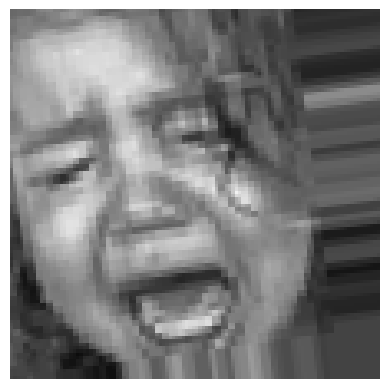

In [ ]:
#Test only!!!!!
images, labels = next(train_generator)    #get the next batch, return a tuple: (images_array, labels_array)
print(images.shape)               #images[64][48][48][1]       "[1] is 1 channel color but int a[1] is the same as int a"
print(labels.shape)               #labels[64][7]
plt.imshow(images[0].squeeze(), cmap='gray')  #images[0] = first image in the batch, squeeze() removes dimensions whose size is 1,
#cmap='gray' => display images[0].squeeze() on the color map of gray scale
plt.axis('off')
plt.show()

This code was generated by Google Gemini with the following prompt: "how to implement transfer learning using cnn models from hugging face?"
Further adjustments have been made to fit to the task

### Model Definition with VGG19 Backbone

This cell defines a new model using `VGG19` as the backbone. The `VGG19` convolutional base is loaded with `imagenet` weights and `include_top=False` to allow us to add our own classification layers. For stability and to leverage the pre-trained features, the entire `VGG19` backbone is initially set to be non-trainable (frozen).

In [ ]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(112, 112, 3))

# Freeze the entire VGG19 backbone to use its pre-trained features
base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

# Apply heavy dropout to force the network to be robust
x = Dropout(0.5)(x)

outputs_vgg19 = keras.layers.Dense(6, activation='softmax')(x)

model = keras.Model(inputs=base_model.input, outputs=outputs_vgg19)

print("Model with VGG19 backbone created.")
model.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model with VGG19 backbone created.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,027,462 (76.40 MB)

 Trainable params: 3,078 (12.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

You will now need to compile and train `model_vgg19` instead of the previous `model` variable. Make sure to use the rescaled `ImageDataGenerator` instances if you adopted the normalization suggestion.

1st Training phase (Header training)

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile with a standard learning rate
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Step 1: Training the Head...")
history_step1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10 # Train just enough to stabilize the random weights
)

Starting Step 1: Training the Head...
Epoch 1/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 125s 162ms/step - accuracy: 0.2730 - loss: 1.7331 - val_accuracy: 0.3309 - val_loss: 1.6196
Epoch 2/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 109s 154ms/step - accuracy: 0.3212 - loss: 1.6442 - val_accuracy: 0.3521 - val_loss: 1.5908
Epoch 3/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 106s 150ms/step - accuracy: 0.3360 - loss: 1.6231 - val_accuracy: 0.3691 - val_loss: 1.5683
Epoch 4/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 105s 149ms/step - accuracy: 0.3392 - loss: 1.6131 - val_accuracy: 0.3686 - val_loss: 1.5635
Epoch 5/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 104s 147ms/step - accuracy: 0.3427 - loss: 1.6110 - val_accuracy: 0.3783 - val_loss: 1.5578
Epoch 6/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 105s 149ms/step - accuracy: 0.3460 - loss: 1.6056 - val_accuracy: 0.3757 - val_loss: 1.5492
Epoch 7/10
707/707 ━━━━━━━━━━━━━━━━━━━━ 106s 149ms/step - accuracy: 0.3425 - loss: 1.6093 - val_accuracy: 0.3643 - val_loss: 1.5559
Epoch 8/10
707/707 ━━━━━━━━━━━━━━━━━━━

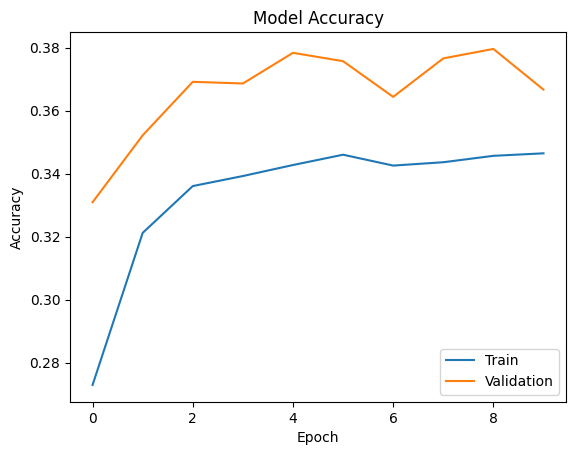

In [ ]:
plt.plot(history_step1.history['accuracy'])
plt.plot(history_step1.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

**2nd Training phase (Unfreeze block 5)**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# 1. Unfreeze the base model so we can target specific layers
base_model.trainable = True

# 2. Loop through the layers.
# Freeze everything EXCEPT the layers in block 5.
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
        print(f"Unfrozen: {layer.name}")
    else:
        layer.trainable = False

lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,   # Drop learning rate to 20% of its current value
    patience=5,   # Trigger this after just 2 stalled epochs
    min_lr=1e-7
)

#The Auto-Cutoff (The Kill Switch)
early_stopping = EarlyStopping(
    min_delta = 0.00005,
    monitor='val_accuracy', # Always monitor loss, NOT accuracy. Loss is more precise.
    patience=5,         # Wait 5 epochs before permanently killing the training
    verbose=1,
    restore_best_weights=True # CRITICAL: Revert to the best epoch automatically
)

# 3. RECOMPILE! (Mandatory step)
# Drop the learning rate significantly (e.g., 1e-5)
model.compile(optimizer=Adam(learning_rate=1e-4), #change to 1e-4 maybe?
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Starting Step 2: Fine-tuning Block 5...")
history_step2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    initial_epoch=history_step1.epoch[-1], # Continues the epoch counter neatly
    callbacks=[lr_scheduler, early_stopping]
)

Unfrozen: block5_conv1
Unfrozen: block5_conv2
Unfrozen: block5_conv3
Unfrozen: block5_conv4
Unfrozen: block5_pool
Starting Step 2: Fine-tuning Block 5...
Epoch 10/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 123s 167ms/step - accuracy: 0.4413 - loss: 1.4167 - val_accuracy: 0.5237 - val_loss: 1.2264 - learning_rate: 1.0000e-04
Epoch 11/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 112s 158ms/step - accuracy: 0.5334 - loss: 1.2148 - val_accuracy: 0.5472 - val_loss: 1.1632 - learning_rate: 1.0000e-04
Epoch 12/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 112s 158ms/step - accuracy: 0.5639 - loss: 1.1447 - val_accuracy: 0.5838 - val_loss: 1.0815 - learning_rate: 1.0000e-04
Epoch 13/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 113s 159ms/step - accuracy: 0.5885 - loss: 1.0773 - val_accuracy: 0.5667 - val_loss: 1.1149 - learning_rate: 1.0000e-04
Epoch 14/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 113s 159ms/step - accuracy: 0.6060 - loss: 1.0325 - val_accuracy: 0.5985 - val_loss: 1.0682 - learning_rate: 1.0000e-04
Epoch 15/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 

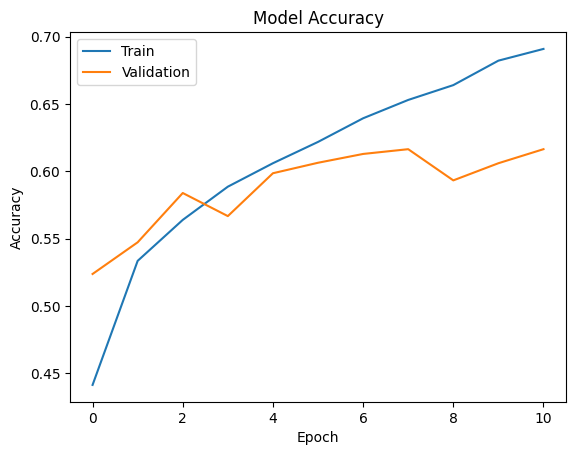

In [ ]:
plt.plot(history_step2.history['accuracy'])
plt.plot(history_step2.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

**3rd Training phase (UNFREEZE ALL)**

In [ ]:
# 1. Loop through the layers again.
# Keep Block 5 unfrozen, and now unfreeze Block 4 as well.
for layer in base_model.layers:
    if 'block5' in layer.name or 'block4' in layer.name or 'block3' in layer.name or 'block2' in layer.name or 'block1' in layer.name:
        layer.trainable = True
        print(f"Unfrozen: {layer.name}")
    else:
        layer.trainable = False

# 2. RECOMPILE AGAIN!
# Drop the learning rate even lower to prevent catastrophic forgetting (e.g., 1e-6)
model.compile(optimizer=Adam(learning_rate=5e-6),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. We highly recommend using Early Stopping here
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True # Reverts if Block 4 causes overfitting
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.4,   # Drop learning rate to 20% of its current value
    patience=5,   # Trigger this after just 2 stalled epochs
    min_lr=1e-7
)

print("Starting Step 3: Fine-tuning Block 4 & 5...")
history_step3 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=55,
    initial_epoch=history_step2.epoch[-1],
    callbacks=[lr_scheduler, early_stopping]
)

Unfrozen: block1_conv1
Unfrozen: block1_conv2
Unfrozen: block1_pool
Unfrozen: block2_conv1
Unfrozen: block2_conv2
Unfrozen: block2_pool
Unfrozen: block3_conv1
Unfrozen: block3_conv2
Unfrozen: block3_conv3
Unfrozen: block3_conv4
Unfrozen: block3_pool
Unfrozen: block4_conv1
Unfrozen: block4_conv2
Unfrozen: block4_conv3
Unfrozen: block4_conv4
Unfrozen: block4_pool
Unfrozen: block5_conv1
Unfrozen: block5_conv2
Unfrozen: block5_conv3
Unfrozen: block5_conv4
Unfrozen: block5_pool
Starting Step 3: Fine-tuning Block 4 & 5...
Epoch 20/55
707/707 ━━━━━━━━━━━━━━━━━━━━ 192s 245ms/step - accuracy: 0.6915 - loss: 0.8172 - val_accuracy: 0.6335 - val_loss: 1.0080 - learning_rate: 5.0000e-06
Epoch 21/55
707/707 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.7037 - loss: 0.7835 - val_accuracy: 0.6204 - val_loss: 1.0334 - learning_rate: 5.0000e-06
Epoch 22/55
707/707 ━━━━━━━━━━━━━━━━━━━━ 158s 223ms/step - accuracy: 0.7114 - loss: 0.7623 - val_accuracy: 0.6339 - val_loss: 1.0121 - learning_rate: 5.0000

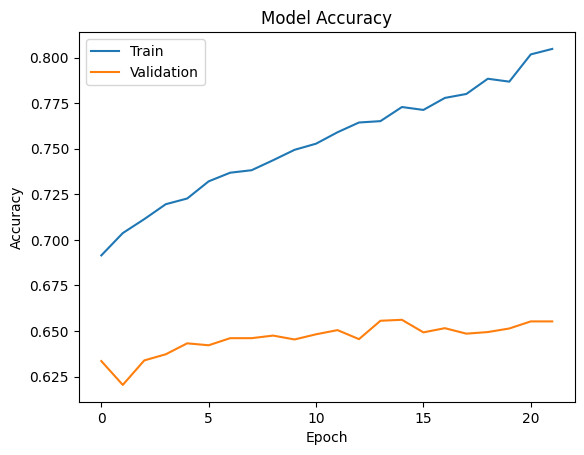

In [ ]:
plt.plot(history_step3.history['accuracy'])
plt.plot(history_step3.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
class_names = list(test_generator.class_indices.keys())

print(class_names)

['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


221/221 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step
[[7.34726787e-01 1.85862646e-01 7.63140991e-02 4.78343427e-05
  3.04500479e-03 3.71041665e-06]
 [9.35256243e-01 9.21957474e-03 4.71521206e-02 2.15002772e-04
  7.99133535e-03 1.65746722e-04]
 [6.14697253e-03 5.05843759e-02 3.46333208e-03 1.83472708e-02
  9.20363605e-01 1.09443301e-03]
 ...
 [7.79370794e-07 1.58332149e-03 1.07789795e-07 9.68254608e-06
  8.57411396e-06 9.98397529e-01]
 [3.58027254e-11 2.91898488e-08 5.25346389e-09 1.09588063e-05
  4.30994129e-12 9.99989033e-01]
 [1.27332099e-03 1.29879164e-02 3.26470397e-02 3.31514492e-03
  6.87350752e-04 9.49089229e-01]]
[0 0 4 ... 5 5 5]
              precision    recall  f1-score   support

       angry       0.64      0.58      0.61       958
        fear       0.53      0.46      0.49      1024
       happy       0.83      0.88      0.85      1774
     neutral       0.58      0.70      0.63      1233
         sad       0.56      0.52      0.54      1247
    surprise       0.78      0.76     

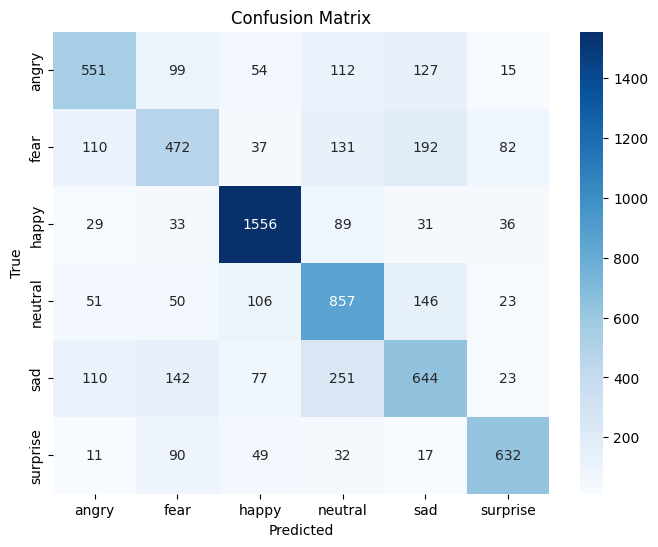

In [ ]:
from sklearn.metrics import classification_report
predictions = model.predict(test_generator)
print(predictions)
y_pred = np.argmax(predictions, axis=1)
print(y_pred)
y_true = test_generator.classes
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()